# 01  ·  Introduction

This is the first of seven walkthrough notebooks for **eeg-cognitive-decoding**.

The project compares two machine-learning pipelines for decoding cognitive
states from scalp EEG:

- **FBCSP + LDA** — the classical filter-bank Common-Spatial-Patterns
  baseline used in BCI competitions for over a decade.
- **EEGNet** — a compact (~2,400-parameter) convolutional network from
  Lawhern et al. 2018, designed specifically for EEG.

Both are run on two qualitatively different cognitive paradigms — motor
imagery (4-class) and mental arithmetic vs. rest (2-class).

This notebook just gets you oriented: load some data, look at it,
visualise a few raw trials. The next six notebooks walk through every
piece of the pipeline in detail.


In [1]:
# Make the eeg_cognitive package importable when running this notebook
# directly out of a clone (no pip install required).
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)


## Generate a small synthetic dataset

For reproducibility we use a physiologically grounded synthetic EEG
generator. Each trial is the sum of pink (1/f) background noise and a
class-specific narrowband signal modulated by a scalp gain map encoding
the textbook ERD/ERS pattern. See `eeg_cognitive/data.py` for the full
implementation.

In [2]:
from eeg_cognitive import make_motor_imagery_synthetic
ds = make_motor_imagery_synthetic(n_subjects=2, trials_per_class=12,
                                  snr_db=-12, seed=0)
print(f"shape:    {ds.X.shape}  (n_trials, n_channels, n_samples)")
print(f"sfreq:    {ds.sfreq} Hz  →  {ds.X.shape[-1]/ds.sfreq:.1f} s per trial")
print(f"channels: {len(ds.ch_names)} = {ds.ch_names[:6]} ...")
print(f"classes:  {ds.class_names}")
print(f"labels:   {ds.y[:10].tolist()} ... (first 10)")


shape:    (96, 22, 500)  (n_trials, n_channels, n_samples)
sfreq:    250.0 Hz  →  2.0 s per trial
channels: 22 = ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4'] ...
classes:  ['left_hand', 'right_hand', 'feet', 'tongue']
labels:   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ... (first 10)


## Look at one trial across all 22 channels

A traditional "EEG strip" — channels stacked vertically, time on the
x-axis. Each channel is a noisy oscillation; the model's job is to figure
out which spatial × spectral pattern distinguishes the four motor-imagery
classes.

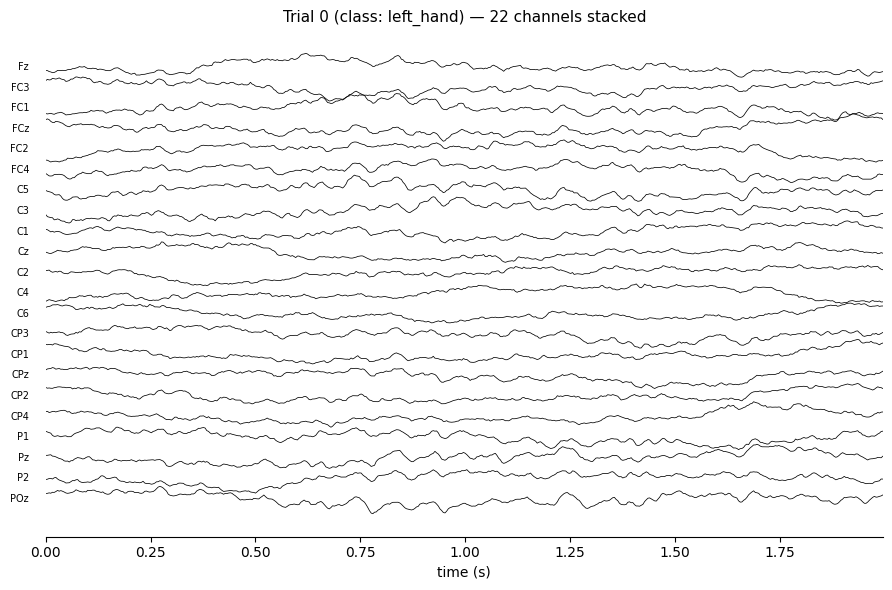

In [3]:
import numpy as np
import matplotlib.pyplot as plt

trial_idx = 0
trial = ds.X[trial_idx]                 # shape (22, n_samples)
truth = ds.class_names[ds.y[trial_idx]]
t = np.arange(trial.shape[1]) / ds.sfreq

fig, ax = plt.subplots(figsize=(9, 6))
spacing = 4 * trial.std()
for i, name in enumerate(ds.ch_names):
    ax.plot(t, trial[i] + (len(ds.ch_names) - 1 - i) * spacing,
            color='black', linewidth=0.55)
    ax.text(-0.04, (len(ds.ch_names) - 1 - i) * spacing, name,
            ha='right', va='center', fontsize=7)
ax.set_xlim(0, t[-1])
ax.set_yticks([]); ax.set_xlabel('time (s)')
ax.set_title(f'Trial 0 (class: {truth}) — 22 channels stacked', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout(); plt.show()


## Class balance

In [4]:
import numpy as np
counts = np.bincount(ds.y)
for cls, n in zip(ds.class_names, counts):
    print(f"  {cls:12s}  {n} trials")
print(f"  total       {len(ds.y)} trials")


  left_hand     24 trials
  right_hand    24 trials
  feet          24 trials
  tongue        24 trials
  total       96 trials


## What's next

- **02** — the synthetic data generator: what's actually in each trial,
  and how class-specific patterns are embedded.
- **03** — preprocessing: bandpass, common-average reference, leakage-free
  per-channel z-scoring.
- **04** — FBCSP + LDA from scratch, with topomaps of the learned spatial filters.
- **05** — EEGNet training, with the first-layer kernels visualised.
- **06** — full results comparison and the cross-subject finding.
- **07** — the live-prediction demo widget for the talk.
